In [72]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import time
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.optimizers import RMSprop


# **Environment Setup**

In [73]:
#loaded the data both are the different files here train and test so thats why two different variables 
#because of two different files
train = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv')
test = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv')

In [74]:
#now its time to get the train and test data ready label column is target coulmn has values 0-9
#i will drop the label for train and test for X
X = train.drop('label', axis=1).values
y = train['label'].values

In [75]:
X_test = test.drop('label', axis=1).values
y_test = test['label'].values

In [76]:
#now i will normalize the values for this i recalled my ds concept to use minmax scalar
# scaler = MinMaxScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

#here i tried to use minmax scalar but by which i was getting a value of 1.3 in test.max() 
#but the assignment requirement was 0-1 so i divided it with max number 255

X = X / 255.0
X_test = X_test / 255.0

print("Training shape:", X.shape)
print("Test shape:", X_test.shape)
print("Training min:", X.min())
print("Training max:", X.max())
print("Test min:", X_test.min())
print("Test max:", X_test.max())

Training shape: (60000, 784)
Test shape: (10000, 784)
Training min: 0.0
Training max: 1.0
Test min: 0.0
Test max: 1.0


In [77]:
#data has already 784 columns so it is falattend already
print("X shape:", X.shape)
print("Test shape:", X_test.shape)

X shape: (60000, 784)
Test shape: (10000, 784)


In [78]:
#train test validation splitting 
#number of sample in each split
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 48000
Validation samples: 12000
Test samples: 10000


In [79]:
#class distritbution 0-9
print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation class distribution:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts().sort_index())


Training class distribution:
0    4800
1    4800
2    4800
3    4800
4    4800
5    4800
6    4800
7    4800
8    4800
9    4800
Name: count, dtype: int64

Validation class distribution:
0    1200
1    1200
2    1200
3    1200
4    1200
5    1200
6    1200
7    1200
8    1200
9    1200
Name: count, dtype: int64

Test class distribution:
0    1000
1    1000
2    1000
3    1000
4    1000
5    1000
6    1000
7    1000
8    1000
9    1000
Name: count, dtype: int64


# PART 1

In [80]:
# ReLU function for hidden layers
def relu(x):
    return np.maximum(0, x)

# Derivative of ReLU
def relu_derivative(x):
    return (x > 0).astype(float)

# Softmax for activation
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# one-hot encoding
def one_hot(y, classes):
    result = np.zeros((y.size, classes))
    result[np.arange(y.size), y] = 1
    return result

# Categorial Cross Entropy Loss Fucntion
def calculate_loss(y, output):
    m = y.shape[0]
    return -np.sum(y * np.log(output + 1e-15)) / m

In [81]:
np.random.seed(42)

#weights and bias
W1 = np.random.randn(784,64) * 0.01
b1 = np.zeros((1, 64))
W2 = np.random.randn(64, 10) * 0.01
b2 = np.zeros((1,10))


#i have to copy for torch
W1_initial = W1.copy()
b1_initial = b1.copy()
W2_initial = W2.copy()
b2_initial = b2.copy()

In [82]:
#Taking only 5000 training samples
X = X_train[0:5000]
y = y_train[0:5000]

#for pytorch need a copy
X_batch = X
y_batch = y

#one-hot encoding for categoeries
y_one_hot = one_hot(y, 10)


#here we will see the results of epochs after 5 iterations
epochs = 20
learning_rate = 0.1
losses = []
for epoch in range(epochs):
    #forward
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)
    loss = calculate_loss(y_one_hot, A2)
    losses.append(loss)

    # Backpropagation
    m = X.shape[0]
    dZ2 = (A2 - y_one_hot) / m
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    #Update
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    if (epoch + 1) % 5 == 0:
        print("Epoch:", epoch + 1, "Loss:", loss)

Epoch: 5 Loss: 2.2980597178845135
Epoch: 10 Loss: 2.2863589031136797
Epoch: 15 Loss: 2.262202776536237
Epoch: 20 Loss: 2.2150265810148526


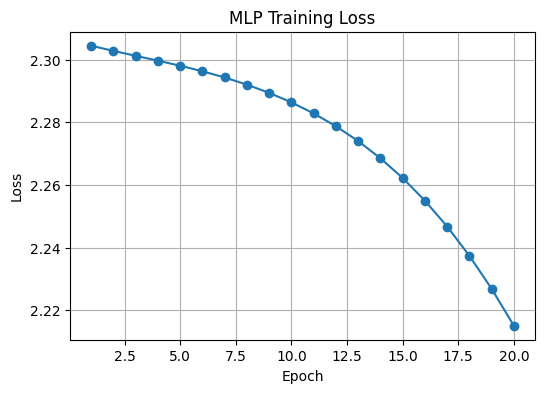

In [83]:
# Plot the loss
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), losses, marker='o')
plt.title("MLP Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [84]:
#pytorch
model = nn.Sequential(nn.Linear(784, 64),nn.ReLU(),
    nn.Linear(64, 10))

#the copies i created in upper cell will be used here 
with torch.no_grad():
    model[0].weight.copy_(torch.tensor(W1_initial.T))
    model[0].bias.copy_(torch.tensor(b1_initial.flatten()))

    model[2].weight.copy_(torch.tensor(W2_initial.T))
    model[2].bias.copy_(torch.tensor(b2_initial.flatten()))

In [85]:
X_torch = torch.tensor(X_batch, dtype=torch.float32)
y_torch = torch.tensor(y_batch, dtype=torch.long)

#Forward
output = model(X_torch)

#loss
loss = nn.CrossEntropyLoss()(output, y_torch)

#Backward
loss.backward()

In [86]:
#pytorch gradiet
dW1_torch = model[0].weight.grad.numpy().T
dW2_torch = model[2].weight.grad.numpy().T

In [87]:
#absolute differ
difference_W1 = np.max(np.abs(dW1 - dW1_torch))
difference_W2 = np.max(np.abs(dW2 - dW2_torch))

print("Maximum difference for W1:", difference_W1)
print("Maximum difference for W2:", difference_W2)


Maximum difference for W1: 0.006655703253986288
Maximum difference for W2: 0.030647578993040124


# PART 2

In [88]:
np.random.seed(42)
tf.random.set_seed(42)

#encoding
y_train_cat = to_categorical(y_train, 10)
y_val_cat = to_categorical(y_val, 10)

In [89]:
X_grad_sample = X_val[0:128]
y_grad_sample = y_val_cat[0:128]

In [90]:
#this will get the gradient i get the issue and get to know
#fit() doesnt give me graident so this will get it
class GradientLogger(tf.keras.callbacks.Callback):
    def __init__(self, X_sample, y_sample):
        super().__init__()
        self.X_sample = X_sample
        self.y_sample = y_sample
        self.grad_history = []

    def on_epoch_end(self, epoch, logs=None):
        with tf.GradientTape() as tape:
            preds = self.model(self.X_sample, training=True)
            loss = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(self.y_sample, preds))

        first_layer_w = self.model.layers[0].trainable_weights[0]
        grad = tape.gradient(loss, [first_layer_w])[0]
        self.grad_history.append(tf.reduce_mean(tf.abs(grad)).numpy())

In [91]:
#Sigmoid
sigmoid_model = Sequential([
    Dense(128, input_dim=784, activation='sigmoid'),
    Dense(64, activation='sigmoid'),
    Dense(10, activation='softmax')
])

sigmoid_model.compile(optimizer=Adam(learning_rate=0.001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

sigmoid_logger = GradientLogger(X_grad_sample, y_grad_sample)

sigmoid_history = sigmoid_model.fit(X_train, y_train_cat,
                                     validation_data=(X_val, y_val_cat),
                                     epochs=5, batch_size=128,
                                     callbacks=[sigmoid_logger],
                                     verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7081 - loss: 0.9415 - val_accuracy: 0.8074 - val_loss: 0.5604
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8311 - loss: 0.4862 - val_accuracy: 0.8357 - val_loss: 0.4511
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8519 - loss: 0.4178 - val_accuracy: 0.8466 - val_loss: 0.4132
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8629 - loss: 0.3845 - val_accuracy: 0.8563 - val_loss: 0.3915
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8706 - loss: 0.3621 - val_accuracy: 0.8624 - val_loss: 0.3766


In [92]:
#TANH
tanh_model = Sequential([
    Dense(128, input_dim=784, activation='tanh'),
    Dense(64, activation='tanh'),
    Dense(10, activation='softmax')
])

tanh_model.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

tanh_logger = GradientLogger(X_grad_sample, y_grad_sample)

tanh_history = tanh_model.fit(X_train, y_train_cat,
                               validation_data=(X_val, y_val_cat),
                               epochs=5, batch_size=128,
                               callbacks=[tanh_logger],
                               verbose=1)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8074 - loss: 0.5532 - val_accuracy: 0.8237 - val_loss: 0.4652
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8581 - loss: 0.3943 - val_accuracy: 0.8418 - val_loss: 0.4180
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8724 - loss: 0.3557 - val_accuracy: 0.8503 - val_loss: 0.3945
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8819 - loss: 0.3306 - val_accuracy: 0.8560 - val_loss: 0.3806
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8876 - loss: 0.3114 - val_accuracy: 0.8588 - val_loss: 0.3739


In [93]:
#RELU 
relu_model = Sequential([
    Dense(128, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

relu_model.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

relu_logger = GradientLogger(X_grad_sample, y_grad_sample)

relu_history = relu_model.fit(X_train, y_train_cat,
                               validation_data=(X_val, y_val_cat),
                               epochs=5, batch_size=128,
                               callbacks=[relu_logger],
                               verbose=1)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7994 - loss: 0.5802 - val_accuracy: 0.8299 - val_loss: 0.4621
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8549 - loss: 0.4088 - val_accuracy: 0.8443 - val_loss: 0.4200
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8693 - loss: 0.3676 - val_accuracy: 0.8425 - val_loss: 0.4207
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8779 - loss: 0.3403 - val_accuracy: 0.8509 - val_loss: 0.3980
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8845 - loss: 0.3188 - val_accuracy: 0.8551 - val_loss: 0.3892


In [94]:
#LEAKY RELU 
leaky_model = Sequential([
    Dense(128, input_dim=784),
    LeakyReLU(alpha=0.01),
    Dense(64),
    LeakyReLU(alpha=0.01),
    Dense(10, activation='softmax')
])

leaky_model.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

leaky_logger = GradientLogger(X_grad_sample, y_grad_sample)

leaky_history = leaky_model.fit(X_train, y_train_cat,
                                 validation_data=(X_val, y_val_cat),
                                 epochs=5, batch_size=128,
                                 callbacks=[leaky_logger],
                                 verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8006 - loss: 0.5806 - val_accuracy: 0.8331 - val_loss: 0.4587
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8551 - loss: 0.4111 - val_accuracy: 0.8447 - val_loss: 0.4171
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8694 - loss: 0.3674 - val_accuracy: 0.8403 - val_loss: 0.4288
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8781 - loss: 0.3407 - val_accuracy: 0.8447 - val_loss: 0.4154
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8854 - loss: 0.3183 - val_accuracy: 0.8440 - val_loss: 0.4137


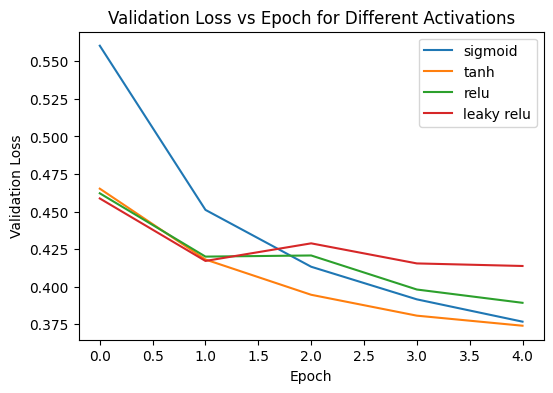

In [95]:
# plotting all 4 val loss curves together
plt.figure(figsize=(6,4))
plt.plot(sigmoid_history.history['val_loss'], label='sigmoid')
plt.plot(tanh_history.history['val_loss'], label='tanh')
plt.plot(relu_history.history['val_loss'], label='relu')
plt.plot(leaky_history.history['val_loss'], label='leaky relu')

plt.title("Validation Loss vs Epoch for Different Activations")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

In [96]:
#epoch 1 and last
print("sigmoid grad epoch 1:", sigmoid_logger.grad_history[0])
print("sigmoid grad last epoch:", sigmoid_logger.grad_history[-1])

print("relu grad epoch 1:", relu_logger.grad_history[0])
print("relu grad last epoch:", relu_logger.grad_history[-1])

sigmoid grad epoch 1: 0.00021280901
sigmoid grad last epoch: 0.00038798177
relu grad epoch 1: 0.0017639976
relu grad last epoch: 0.0022291192


so by this we can see that for the sigmoid the learning is very less as compared to the relu as there is difference in both values for sigmoid and relu

so in short words the relu provides a better learning as compared to the sigmoid


In [97]:
#if output is 0 it is dead relu
W1_relu, b1_relu = relu_model.layers[0].get_weights()

Z1 = np.dot(X_val[:256], W1_relu) + b1_relu
A1 = relu(Z1)   #relu from p1

dead_units = np.all(A1 == 0, axis=0) #check all
dead_percentage = np.mean(dead_units) * 100
print("percentage of dead relu units:", dead_percentage, "%")

percentage of dead relu units: 8.59375 %


3.9% are 0 this is very small ratio and i think it is not that concerning but to name it this is the dying relu problem for which solution exists but here the number is small so we will ignore it the solution to solve the dying relu problem is >* Leaky Relu (0.01x,x)*

# PART 3

here i am using sample data set of diabetes which i explored on
https://scikit-learn.org/stable/datasets/toy_dataset.html

In [98]:
#CROSS ENTROPY MODEL
#using the same relu architecture from part 2 (128, 64)
ce_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

ce_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

ce_history = ce_model.fit(X_train, y_train_cat,
                           validation_data=(X_val, y_val_cat),
                           epochs=5, batch_size=128,
                           verbose=1)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8168 - loss: 0.5247 - val_accuracy: 0.8559 - val_loss: 0.4069
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8649 - loss: 0.3805 - val_accuracy: 0.8688 - val_loss: 0.3581
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8784 - loss: 0.3370 - val_accuracy: 0.8700 - val_loss: 0.3490
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8883 - loss: 0.3079 - val_accuracy: 0.8629 - val_loss: 0.3646
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8957 - loss: 0.2879 - val_accuracy: 0.8624 - val_loss: 0.3624


In [99]:
y_test_cat = to_categorical(y_test, 10)

ce_test_loss, ce_test_acc = ce_model.evaluate(X_test, y_test_cat, verbose=0)
print("cross entropy test accuracy:", ce_test_acc)

cross entropy test accuracy: 0.8616999983787537


In [100]:
#MSE MODEL 
#same as above only loss function differ
mse_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

mse_model.compile(optimizer=Adam(learning_rate=0.001),
                   loss='mean_squared_error',
                   metrics=['accuracy'])

mse_history = mse_model.fit(X_train, y_train_cat,
                             validation_data=(X_val, y_val_cat),
                             epochs=5, batch_size=128,
                             verbose=1)

mse_test_loss, mse_test_acc = mse_model.evaluate(X_test, y_test_cat, verbose=0)
print("mse test accuracy:", mse_test_acc)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8108 - loss: 0.0273 - val_accuracy: 0.8262 - val_loss: 0.0249
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8588 - loss: 0.0206 - val_accuracy: 0.8225 - val_loss: 0.0255
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8741 - loss: 0.0186 - val_accuracy: 0.8431 - val_loss: 0.0221
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8835 - loss: 0.0172 - val_accuracy: 0.8467 - val_loss: 0.0221
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8899 - loss: 0.0163 - val_accuracy: 0.8582 - val_loss: 0.0207
mse test accuracy: 0.8537999987602234


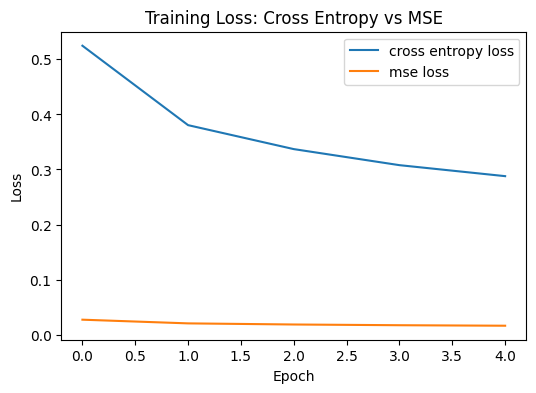

In [101]:
plt.figure(figsize=(6,4))
plt.plot(ce_history.history['loss'], label='cross entropy loss')
plt.plot(mse_history.history['loss'], label='mse loss')
plt.title("Training Loss: Cross Entropy vs MSE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Diabetes DataSet**

In [102]:
diabetes = load_diabetes()
X_diab = diabetes.data
y_diab = diabetes.target

print("X shape:", X_diab.shape)
print("y sample:", y_diab[0:5])

X shape: (442, 10)
y sample: [151.  75. 141. 206. 135.]


In [103]:
X_diab_train, X_diab_test, y_diab_train, y_diab_test = train_test_split(
    X_diab, y_diab, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_diab_train = scaler.fit_transform(X_diab_train)
X_diab_test = scaler.transform(X_diab_test)

In [104]:
reg_model = Sequential([
    Dense(40, input_dim=X_diab_train.shape[1], activation='relu'),
    Dense(20, activation='relu'),
    Dense(1)  #no activation function as this is regression
])

reg_model.compile(optimizer=Adam(learning_rate=0.01),
                   loss='mse',
                   metrics=['mae'])

reg_history = reg_model.fit(X_diab_train, y_diab_train,
                             validation_split=0.2,
                             epochs=50, batch_size=20,
                             verbose=1)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 30650.9961 - mae: 156.0102 - val_loss: 20372.5117 - val_mae: 126.5470
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 24902.0801 - mae: 138.6123 - val_loss: 13424.4668 - val_mae: 99.5826
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 11589.2021 - mae: 86.7294 - val_loss: 4590.8760 - val_mae: 50.0269
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6042.3335 - mae: 59.3609 - val_loss: 3484.3914 - val_mae: 45.5066
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4147.9590 - mae: 51.0781 - val_loss: 3356.8469 - val_mae: 42.4603
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3546.4790 - mae: 47.0128 - val_loss: 2941.7590 - val_mae: 40.2837
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3211.2363 - mae: 44.5169 - val_loss: 2808.0549 - val_mae: 40.0537
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3066.7366 - mae: 43.8984 - val_loss: 2740.2866 - val_mae: 40.0881
Epoch 9/50

In [105]:
y_diab_pred = reg_model.predict(X_diab_test)

mse_val = mean_squared_error(y_diab_test, y_diab_pred)
rmse_val = np.sqrt(mse_val)
mae_val = mean_absolute_error(y_diab_test, y_diab_pred)

print("MSE:", mse_val)
print("RMSE:", rmse_val)
print("MAE:", mae_val)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
MSE: 2635.921723197204
RMSE: 51.341228298485454
MAE: 41.382954243863566


When the MSE is combined with softmax it produces small gradients so by this the learning becomes slow but on the other hand corss-entropy with softmax the output is large as compared to MSE so it pushes the weights towards the correct answer

# PART 4

In [106]:
#Optimsers
def epochs_to_reach(history, target=0.85):
    val_acc = history.history['val_accuracy']

    epoch = 1

    for acc in val_acc:
        if acc >= target:
            return epoch
        epoch += 1

    return None
#loop for tracking epochs catch when accuracy gets 85

In [107]:
#SGD plain
sgd_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

sgd_model.compile(optimizer=SGD(learning_rate=0.01),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

start = time.time()
sgd_history = sgd_model.fit(X_train, y_train_cat,
                             validation_data=(X_val, y_val_cat),
                             epochs=20, batch_size=100,
                             verbose=1)
sgd_time = time.time() - start

print("sgd epochs to 85%:", epochs_to_reach(sgd_history))
print("sgd final val acc:", sgd_history.history['val_accuracy'][-1])
print("sgd wall clock time:", sgd_time)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6996 - loss: 1.0075 - val_accuracy: 0.7697 - val_loss: 0.6937
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7992 - loss: 0.6141 - val_accuracy: 0.7972 - val_loss: 0.5832
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8192 - loss: 0.5403 - val_accuracy: 0.8065 - val_loss: 0.5399
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8296 - loss: 0.5027 - val_accuracy: 0.8126 - val_loss: 0.5175
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8363 - loss: 0.4786 - val_accuracy: 0.8138 - val_loss: 0.5035
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8410 - loss: 0.4612 - val_accuracy: 0.8166 - val_loss: 0.4932
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8456 - loss: 0.4475 - val_accuracy: 0.8196 - val_loss: 0.4846
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8484 - loss: 0.4362 - val_accuracy: 0.

In [108]:
#SGD with momentum

sgd_mom_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

sgd_mom_model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

start = time.time()
sgd_mom_history = sgd_mom_model.fit(X_train, y_train_cat,
                                     validation_data=(X_val, y_val_cat),
                                     epochs=20, batch_size=100,
                                     verbose=1)
sgd_mom_time = time.time() - start

print("sgd+momentum epochs to 85%:", epochs_to_reach(sgd_mom_history))
print("sgd+momentum final val acc:", sgd_mom_history.history['val_accuracy'][-1])
print("sgd+momentum wall clock time:", sgd_mom_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7905 - loss: 0.6132 - val_accuracy: 0.8367 - val_loss: 0.4589
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8496 - loss: 0.4250 - val_accuracy: 0.8511 - val_loss: 0.4139
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8652 - loss: 0.3798 - val_accuracy: 0.8571 - val_loss: 0.3920
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8746 - loss: 0.3501 - val_accuracy: 0.8598 - val_loss: 0.3784
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8812 - loss: 0.3290 - val_accuracy: 0.8636 - val_loss: 0.3687
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8870 - loss: 0.3120 - val_accuracy: 0.8602 - val_loss: 0.3696
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8920 - loss: 0.2973 - val_accuracy: 0.8627 - val_loss: 0.3636
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8973 - loss: 0.2834 - val_accuracy: 0.

In [109]:
#RMSProp
rms_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

rms_model.compile(optimizer=RMSprop(learning_rate=0.01),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

start = time.time()
rms_history = rms_model.fit(X_train, y_train_cat,
                             validation_data=(X_val, y_val_cat),
                             epochs=20, batch_size=100,
                             verbose=1)
rms_time = time.time() - start

print("rmsprop epochs to 85%:", epochs_to_reach(rms_history))
print("rmsprop final val acc:", rms_history.history['val_accuracy'][-1])
print("rmsprop wall clock time:", rms_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7454 - loss: 1.0545 - val_accuracy: 0.8082 - val_loss: 0.5236
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8309 - loss: 0.4731 - val_accuracy: 0.8311 - val_loss: 0.4619
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8451 - loss: 0.4403 - val_accuracy: 0.8518 - val_loss: 0.4342
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8509 - loss: 0.4219 - val_accuracy: 0.8218 - val_loss: 0.4975
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8553 - loss: 0.4183 - val_accuracy: 0.8387 - val_loss: 0.5075
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8587 - loss: 0.4115 - val_accuracy: 0.8566 - val_loss: 0.4395
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8605 - loss: 0.4094 - val_accuracy: 0.8522 - val_loss: 0.4746
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8653 - loss: 0.3989 - val_accuracy: 0.

In [110]:
#Adam
adam_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

adam_model.compile(optimizer=Adam(learning_rate=0.01),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

start = time.time()
adam_history = adam_model.fit(X_train, y_train_cat,
                               validation_data=(X_val, y_val_cat),
                               epochs=20, batch_size=100,
                               verbose=1)
adam_time = time.time() - start

print("adam epochs to 85%:", epochs_to_reach(adam_history))
print("adam final val acc:", adam_history.history['val_accuracy'][-1])
print("adam wall clock time:", adam_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7891 - loss: 0.6367 - val_accuracy: 0.8393 - val_loss: 0.4384
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8517 - loss: 0.4105 - val_accuracy: 0.8455 - val_loss: 0.4228
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8632 - loss: 0.3790 - val_accuracy: 0.8508 - val_loss: 0.3924
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8701 - loss: 0.3563 - val_accuracy: 0.8586 - val_loss: 0.3786
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8745 - loss: 0.3424 - val_accuracy: 0.8443 - val_loss: 0.4277
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8770 - loss: 0.3351 - val_accuracy: 0.8532 - val_loss: 0.4173
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8821 - loss: 0.3242 - val_accuracy: 0.8578 - val_loss: 0.3963
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8823 - loss: 0.3270 - val_accuracy: 0.

In [111]:
#TUNED LEARNING RATE PER OPTIMISER

In [112]:
# SGD tuned
sgd_tuned_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

sgd_tuned_model.compile(optimizer=SGD(learning_rate=0.1),
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

start = time.time()
sgd_tuned_history = sgd_tuned_model.fit(X_train, y_train_cat,
                                         validation_data=(X_val, y_val_cat),
                                         epochs=20, batch_size=100,
                                         verbose=1)
sgd_tuned_time = time.time() - start

print("sgd tuned epochs to 85%:", epochs_to_reach(sgd_tuned_history))
print("sgd tuned final val acc:", sgd_tuned_history.history['val_accuracy'][-1])
print("sgd tuned wall clock time:", sgd_tuned_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7762 - loss: 0.6342 - val_accuracy: 0.7446 - val_loss: 0.6125
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8410 - loss: 0.4408 - val_accuracy: 0.7639 - val_loss: 0.5716
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8569 - loss: 0.3921 - val_accuracy: 0.7878 - val_loss: 0.5232
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8676 - loss: 0.3621 - val_accuracy: 0.8037 - val_loss: 0.4906
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8749 - loss: 0.3395 - val_accuracy: 0.8265 - val_loss: 0.4492
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8813 - loss: 0.3208 - val_accuracy: 0.8330 - val_loss: 0.4338
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8876 - loss: 0.3053 - val_accuracy: 0.8447 - val_loss: 0.4054
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8925 - loss: 0.2914 - val_accuracy: 0.

In [113]:
#SGD + momentum tuned
sgd_mom_tuned_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

sgd_mom_tuned_model.compile(optimizer=SGD(learning_rate=0.05, momentum=0.9),
                             loss='categorical_crossentropy',
                             metrics=['accuracy'])

start = time.time()
sgd_mom_tuned_history = sgd_mom_tuned_model.fit(X_train, y_train_cat,
                                                 validation_data=(X_val, y_val_cat),
                                                 epochs=20, batch_size=100,
                                                 verbose=1)
sgd_mom_tuned_time = time.time() - start

print("sgd+momentum tuned epochs to 85%:", epochs_to_reach(sgd_mom_tuned_history))
print("sgd+momentum tuned final val acc:", sgd_mom_tuned_history.history['val_accuracy'][-1])
print("sgd+momentum tuned wall clock time:", sgd_mom_tuned_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8005 - loss: 0.5549 - val_accuracy: 0.8478 - val_loss: 0.4321
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8524 - loss: 0.3989 - val_accuracy: 0.8630 - val_loss: 0.3904
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8690 - loss: 0.3542 - val_accuracy: 0.8662 - val_loss: 0.3641
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8775 - loss: 0.3285 - val_accuracy: 0.8723 - val_loss: 0.3481
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8854 - loss: 0.3075 - val_accuracy: 0.8693 - val_loss: 0.3573
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8920 - loss: 0.2912 - val_accuracy: 0.8633 - val_loss: 0.3646
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8966 - loss: 0.2777 - val_accuracy: 0.8758 - val_loss: 0.3525
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8980 - loss: 0.2700 - val_accuracy: 0.

In [114]:
#RMSProp tuned
rms_tuned_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

rms_tuned_model.compile(optimizer=RMSprop(learning_rate=0.001),
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

start = time.time()
rms_tuned_history = rms_tuned_model.fit(X_train, y_train_cat,
                                         validation_data=(X_val, y_val_cat),
                                         epochs=20, batch_size=100,
                                         verbose=1)
rms_tuned_time = time.time() - start

print("rmsprop tuned epochs to 85%:", epochs_to_reach(rms_tuned_history))
print("rmsprop tuned final val acc:", rms_tuned_history.history['val_accuracy'][-1])
print("rmsprop tuned wall clock time:", rms_tuned_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7874 - loss: 0.5861 - val_accuracy: 0.7908 - val_loss: 0.5128
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8512 - loss: 0.4002 - val_accuracy: 0.8253 - val_loss: 0.4434
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8699 - loss: 0.3517 - val_accuracy: 0.8395 - val_loss: 0.4078
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8805 - loss: 0.3209 - val_accuracy: 0.8488 - val_loss: 0.3887
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8884 - loss: 0.2985 - val_accuracy: 0.8599 - val_loss: 0.3624
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8956 - loss: 0.2797 - val_accuracy: 0.8698 - val_loss: 0.3526
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9009 - loss: 0.2655 - val_accuracy: 0.8703 - val_loss: 0.3688
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9052 - loss: 0.2525 - val_accuracy: 0.

In [115]:
#Adam tuned
adam_tuned_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

adam_tuned_model.compile(optimizer=Adam(learning_rate=0.001),
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])

start = time.time()
adam_tuned_history = adam_tuned_model.fit(X_train, y_train_cat,
                                           validation_data=(X_val, y_val_cat),
                                           epochs=20, batch_size=100,
                                           verbose=1)
adam_tuned_time = time.time() - start

print("adam tuned epochs to 85%:", epochs_to_reach(adam_tuned_history))
print("adam tuned final val acc:", adam_tuned_history.history['val_accuracy'][-1])
print("adam tuned wall clock time:", adam_tuned_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8129 - loss: 0.5260 - val_accuracy: 0.8583 - val_loss: 0.3988
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8638 - loss: 0.3772 - val_accuracy: 0.8681 - val_loss: 0.3609
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8796 - loss: 0.3322 - val_accuracy: 0.8745 - val_loss: 0.3473
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8890 - loss: 0.3035 - val_accuracy: 0.8693 - val_loss: 0.3518
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8948 - loss: 0.2859 - val_accuracy: 0.8608 - val_loss: 0.3792
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8993 - loss: 0.2715 - val_accuracy: 0.8650 - val_loss: 0.3723
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9064 - loss: 0.2549 - val_accuracy: 0.8684 - val_loss: 0.3631
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9107 - loss: 0.2423 - val_accuracy: 0.

In [116]:
#table for compare
results_table = pd.DataFrame({
    "Optimiser": ["SGD", "SGD+Momentum", "RMSProp", "Adam"],
    "Learning rate": [0.1, 0.05, 0.001, 0.001],
    "Epochs to 85% val acc": [
        epochs_to_reach(sgd_tuned_history),
        epochs_to_reach(sgd_mom_tuned_history),
        epochs_to_reach(rms_tuned_history),
        epochs_to_reach(adam_tuned_history)
    ],
    "Final val accuracy": [
        sgd_tuned_history.history['val_accuracy'][-1],
        sgd_mom_tuned_history.history['val_accuracy'][-1],
        rms_tuned_history.history['val_accuracy'][-1],
        adam_tuned_history.history['val_accuracy'][-1]
    ],
    "Wall clock time (s)": [sgd_tuned_time, sgd_mom_tuned_time, rms_tuned_time, adam_tuned_time]
})

results_table

,Optimiser,Learning rate,Epochs to 85% val acc,Final val accuracy,Wall clock time (s)
0,SGD,0.100,9,0.860000,29.204398
1,SGD+Momentum,0.050,2,0.863583,30.340685
2,RMSProp,0.001,5,0.877917,30.258887
3,Adam,0.001,1,0.871583,31.263002


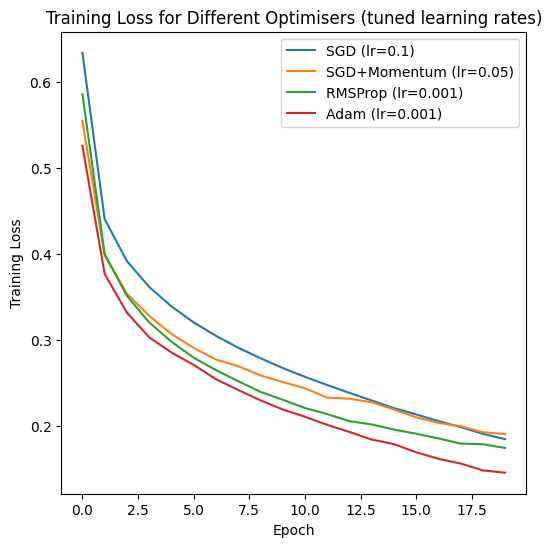

In [117]:
plt.figure(figsize=(6,6))
plt.plot(sgd_tuned_history.history['loss'], label='SGD (lr=0.1)')
plt.plot(sgd_mom_tuned_history.history['loss'], label='SGD+Momentum (lr=0.05)')
plt.plot(rms_tuned_history.history['loss'], label='RMSProp (lr=0.001)')
plt.plot(adam_tuned_history.history['loss'], label='Adam (lr=0.001)')

plt.title("Training Loss for Different Optimisers (tuned learning rates)")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.show()

Based on the Results I would choose RMSProp beacuse it reaches validaton accuracy in 3 epochs and further more it has final accuracy of 87% which is best among all even if i see the time it is win win situation

# PART 5

In [118]:
X_train_small = X_train[0:2000]
y_train_small_cat = y_train_cat[0:2000]

print("small training set shape:", X_train_small.shape)

small training set shape: (2000, 784)


In [119]:

overfit_model = Sequential([
    Dense(512, input_dim=784, activation='relu'),
    Dense(512, activation='relu'),
    Dense(512, activation='relu'),
    Dense(512, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [120]:
overfit_model.compile(optimizer=Adam(learning_rate=0.001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

In [121]:
overfit_model.summary()

Model: "sequential_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_155 (Dense)               │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_156 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_157 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_158 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_159 (Dense)               │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,195,018 (4.56 MB)

 Trainable params: 1,195,018 (4.56 MB)

 Non-trainable params: 0 (0.00 B)

In [122]:
#first i ran 40 to check what is happeining later i change it to 80 
overfit_history = overfit_model.fit(X_train_small, y_train_small_cat,
                                     validation_data=(X_val, y_val_cat),
                                     epochs=80, batch_size=100,
                                     verbose=1)

Epoch 1/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.5825 - loss: 1.2191 - val_accuracy: 0.6981 - val_loss: 0.7938
Epoch 2/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7475 - loss: 0.6739 - val_accuracy: 0.7440 - val_loss: 0.6710
Epoch 3/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8100 - loss: 0.5183 - val_accuracy: 0.8039 - val_loss: 0.5546
Epoch 4/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8415 - loss: 0.4461 - val_accuracy: 0.7962 - val_loss: 0.5570
Epoch 5/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8565 - loss: 0.3871 - val_accuracy: 0.7911 - val_loss: 0.5770
Epoch 6/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8735 - loss: 0.3461 - val_accuracy: 0.8121 - val_loss: 0.5474
Epoch 7/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8860 - loss: 0.3155 - val_accuracy: 0.7858 - val_loss: 0.6084
Epoch 8/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8925 - loss: 0.2761 - val_accuracy: 0.7933 - v

In [123]:
final_train_acc = overfit_history.history['accuracy'][-1]
print("final train accuracy:", final_train_acc)

if final_train_acc < 0.99:
    print("train accuracy did not cross 99%, might need more epochs")

final train accuracy: 0.9955000281333923


In [124]:
#differ b/w trainig and validation accuracy
train_loss = overfit_history.history['loss']
val_loss = overfit_history.history['val_loss']

gap = []

for i in range(len(train_loss)):
    gap.append(val_loss[i] - train_loss[i])

separation_epoch = None

for i in range(len(gap)):
    if gap[i] > 0.1:
        separation_epoch = i + 1
        break

print("epoch where start separating:", separation_epoch)

epoch where start separating: 4


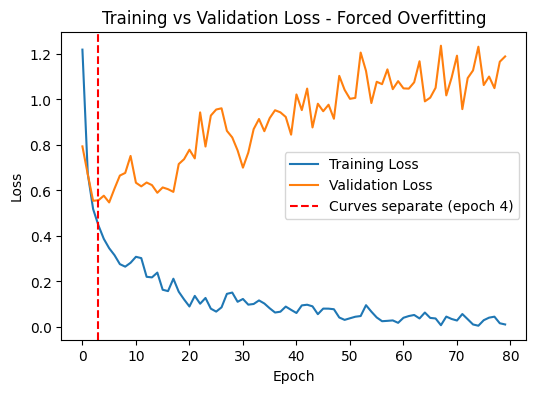

In [125]:
plt.figure(figsize=(6,4))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')

if separation_epoch is not None:
    plt.axvline(x=separation_epoch - 1, color='red', linestyle='--',
                label=f'Curves separate (epoch {separation_epoch})')

plt.title("Training vs Validation Loss - Forced Overfitting")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [126]:
#generalisation=train accuracy-val accuracy
final_train_acc = overfit_history.history['accuracy'][-1]
final_val_acc = overfit_history.history['val_accuracy'][-1]

gen_gap = final_train_acc - final_val_acc

print("final train accuracy:", final_train_acc)
print("final val accuracy:", final_val_acc)
print("generalisation gap:", gen_gap)

final train accuracy: 0.9955000281333923
final val accuracy: 0.8267499804496765
generalisation gap: 0.16875004768371582


by the numbers it is stated that the model has high variance not hight biasness trainig is at 99% validation stayed at 81% so according to me this is variance also we can see the gap b/w them is 17%

# PART 6

In [127]:
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [128]:
# Testing with L2 WEIGHT DECAY and LAMBDA = 0.0001
l2_model_1 = Sequential([
    Dense(512, input_dim=784, activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
    Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
    Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
    Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
    Dense(10, activation='softmax')
])

l2_model_1.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

l2_history_1 = l2_model_1.fit(X_train_small, y_train_small_cat,
                               validation_data=(X_val, y_val_cat),
                               epochs=50, batch_size=70,
                               verbose=1)

l2_train_acc_1 = l2_history_1.history['accuracy'][-1]
l2_val_acc_1 = l2_history_1.history['val_accuracy'][-1]
print("l2 (0.0001) train acc:", l2_train_acc_1, "val acc:", l2_val_acc_1)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.5840 - loss: 1.3392 - val_accuracy: 0.7368 - val_loss: 0.9075
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7685 - loss: 0.8244 - val_accuracy: 0.7745 - val_loss: 0.8149
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8100 - loss: 0.6888 - val_accuracy: 0.7957 - val_loss: 0.7498
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8475 - loss: 0.5801 - val_accuracy: 0.7833 - val_loss: 0.7953
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8555 - loss: 0.5439 - val_accuracy: 0.8094 - val_loss: 0.7400
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8795 - loss: 0.5127 - val_accuracy: 0.8027 - val_loss: 0.7777
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8840 - loss: 0.4755 - val_accuracy: 0.8074 - val_loss: 0.7620
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8875 - loss: 0.4654 - val_accuracy: 0.7941 - v

In [129]:
# Testing with L2 WEIGHT DECAY and LAMBDA = 0.001
l2_model_2 = Sequential([
    Dense(512, input_dim=784, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(10, activation='softmax')
])

l2_model_2.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

l2_history_2 = l2_model_2.fit(X_train_small, y_train_small_cat,
                               validation_data=(X_val, y_val_cat),
                               epochs=50, batch_size=70,
                               verbose=1)

l2_train_acc_2 = l2_history_2.history['accuracy'][-1]
l2_val_acc_2 = l2_history_2.history['val_accuracy'][-1]
print("l2 (0.001) train acc:", l2_train_acc_2, "val acc:", l2_val_acc_2)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.5835 - loss: 2.9720 - val_accuracy: 0.7049 - val_loss: 2.3119
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7595 - loss: 2.0592 - val_accuracy: 0.7637 - val_loss: 1.8930
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8025 - loss: 1.7214 - val_accuracy: 0.8025 - val_loss: 1.6516
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8320 - loss: 1.5140 - val_accuracy: 0.7998 - val_loss: 1.5756
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8490 - loss: 1.3534 - val_accuracy: 0.8202 - val_loss: 1.4265
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8610 - loss: 1.2418 - val_accuracy: 0.7987 - val_loss: 1.4260
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8555 - loss: 1.2043 - val_accuracy: 0.8046 - val_loss: 1.3674
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8705 - loss: 1.1198 - val_accuracy: 0.7926 - v

In [130]:
# Testing with L2 WEIGHT DECAY and LAMBDA = 0.01
l2_model_3 = Sequential([
    Dense(512, input_dim=784, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dense(10, activation='softmax')
])

l2_model_3.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

l2_history_3 = l2_model_3.fit(X_train_small, y_train_small_cat,
                               validation_data=(X_val, y_val_cat),
                               epochs=50, batch_size=70,
                               verbose=1)

l2_train_acc_3 = l2_history_3.history['accuracy'][-1]
l2_val_acc_3 = l2_history_3.history['val_accuracy'][-1]
print("l2 (0.01) train acc:", l2_train_acc_3, "val acc:", l2_val_acc_3)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.5360 - loss: 15.7694 - val_accuracy: 0.6562 - val_loss: 9.8413
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7165 - loss: 7.1640 - val_accuracy: 0.7348 - val_loss: 5.1172
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7560 - loss: 4.1101 - val_accuracy: 0.7651 - val_loss: 3.3172
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7735 - loss: 2.8687 - val_accuracy: 0.7737 - val_loss: 2.4900
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7890 - loss: 2.2231 - val_accuracy: 0.7726 - val_loss: 1.9971
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7985 - loss: 1.8348 - val_accuracy: 0.7848 - val_loss: 1.6988
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8005 - loss: 1.5608 - val_accuracy: 0.7472 - val_loss: 1.5619
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8050 - loss: 1.3657 - val_accuracy: 0.7651 - 

In [131]:
# Testing with L1 PENALTY
l1_model = Sequential([
    Dense(512, input_dim=784, activation='relu', kernel_regularizer=regularizers.l1(0.0001)),
    Dense(512, activation='relu', kernel_regularizer=regularizers.l1(0.0001)),
    Dense(512, activation='relu', kernel_regularizer=regularizers.l1(0.0001)),
    Dense(512, activation='relu', kernel_regularizer=regularizers.l1(0.0001)),
    Dense(10, activation='softmax')
])

l1_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

l1_history = l1_model.fit(X_train_small, y_train_small_cat,
                           validation_data=(X_val, y_val_cat),
                           epochs=50, batch_size=70,
                           verbose=1)

l1_train_acc = l1_history.history['accuracy'][-1]
l1_val_acc = l1_history.history['val_accuracy'][-1]
print("l1 train acc:", l1_train_acc, "val acc:", l1_val_acc)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.5950 - loss: 4.9317 - val_accuracy: 0.7394 - val_loss: 4.0311
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7545 - loss: 3.6170 - val_accuracy: 0.7742 - val_loss: 3.2493
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7950 - loss: 3.0048 - val_accuracy: 0.7750 - val_loss: 2.8866
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8160 - loss: 2.6481 - val_accuracy: 0.7829 - val_loss: 2.6616
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8375 - loss: 2.4234 - val_accuracy: 0.7934 - val_loss: 2.4895
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8480 - loss: 2.2470 - val_accuracy: 0.7719 - val_loss: 2.4214
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8500 - loss: 2.1305 - val_accuracy: 0.7736 - val_loss: 2.2447
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8580 - loss: 2.0077 - val_accuracy: 0.8049 - v

In [132]:
#checking what percentage of weights across the whole network are basically pushed to zero
all_weights = []
for layer in l1_model.layers:
    w = layer.get_weights()
    if len(w) > 0:
        all_weights.append(w[0].flatten())  

all_weights = np.concatenate(all_weights)
small_weight_pct = np.mean(np.abs(all_weights) < 1e-3) * 100

print("percentage of weights below 1e-3:", small_weight_pct)

percentage of weights below 1e-3: 83.65636735515022


In [133]:
# Testing with DROPOUT and RATE = 0.2 
dropout_model_1 = Sequential([
    Dense(512, input_dim=784, activation='relu'),
    Dropout(0.2),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

dropout_model_1.compile(optimizer=Adam(learning_rate=0.001),
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

dropout_history_1 = dropout_model_1.fit(X_train_small, y_train_small_cat,
                                         validation_data=(X_val, y_val_cat),
                                         epochs=50, batch_size=70,
                                         verbose=1)

dropout_train_acc_1 = dropout_history_1.history['accuracy'][-1]
dropout_val_acc_1 = dropout_history_1.history['val_accuracy'][-1]
print("dropout (0.2) train acc:", dropout_train_acc_1, "val acc:", dropout_val_acc_1)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - accuracy: 0.5005 - loss: 1.3888 - val_accuracy: 0.6365 - val_loss: 0.8882
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7070 - loss: 0.8037 - val_accuracy: 0.7495 - val_loss: 0.6806
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7710 - loss: 0.6097 - val_accuracy: 0.7829 - val_loss: 0.6082
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8030 - loss: 0.5308 - val_accuracy: 0.7992 - val_loss: 0.5815
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8225 - loss: 0.4876 - val_accuracy: 0.8019 - val_loss: 0.5662
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8475 - loss: 0.4241 - val_accuracy: 0.8177 - val_loss: 0.5349
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8485 - loss: 0.4163 - val_accuracy: 0.8087 - val_loss: 0.5520
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8535 - loss: 0.3850 - val_accuracy: 0.8189 - 

In [134]:
# Testing with DROPOUT and RATE = 0.4 
dropout_model_2 = Sequential([
    Dense(512, input_dim=784, activation='relu'),
    Dropout(0.4),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(10, activation='softmax')
])

dropout_model_2.compile(optimizer=Adam(learning_rate=0.001),
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

dropout_history_2 = dropout_model_2.fit(X_train_small, y_train_small_cat,
                                         validation_data=(X_val, y_val_cat),
                                         epochs=50, batch_size=70,
                                         verbose=1)

dropout_train_acc_2 = dropout_history_2.history['accuracy'][-1]
dropout_val_acc_2 = dropout_history_2.history['val_accuracy'][-1]
print("dropout (0.4) train acc:", dropout_train_acc_2, "val acc:", dropout_val_acc_2)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - accuracy: 0.3075 - loss: 1.8183 - val_accuracy: 0.5570 - val_loss: 1.1004
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5800 - loss: 1.1018 - val_accuracy: 0.6879 - val_loss: 0.7897
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6620 - loss: 0.8795 - val_accuracy: 0.7180 - val_loss: 0.6889
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7070 - loss: 0.7538 - val_accuracy: 0.7464 - val_loss: 0.6372
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7570 - loss: 0.6699 - val_accuracy: 0.7668 - val_loss: 0.6036
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7690 - loss: 0.6129 - val_accuracy: 0.7764 - val_loss: 0.6051
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7920 - loss: 0.5745 - val_accuracy: 0.7843 - val_loss: 0.5679
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7920 - loss: 0.5485 - val_accuracy: 0.8002 - 

In [135]:
# Testing with DROPOUT and RATE = 0.6
dropout_model_3 = Sequential([
    Dense(512, input_dim=784, activation='relu'),
    Dropout(0.6),
    Dense(512, activation='relu'),
    Dropout(0.6),
    Dense(512, activation='relu'),
    Dropout(0.6),
    Dense(512, activation='relu'),
    Dropout(0.6),
    Dense(10, activation='softmax')
])

dropout_model_3.compile(optimizer=Adam(learning_rate=0.001),
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

dropout_history_3 = dropout_model_3.fit(X_train_small, y_train_small_cat,
                                         validation_data=(X_val, y_val_cat),
                                         epochs=50, batch_size=70,
                                         verbose=1)

dropout_train_acc_3 = dropout_history_3.history['accuracy'][-1]
dropout_val_acc_3 = dropout_history_3.history['val_accuracy'][-1]
print("dropout (0.6) train acc:", dropout_train_acc_3, "val acc:", dropout_val_acc_3)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - accuracy: 0.1280 - loss: 2.4152 - val_accuracy: 0.3586 - val_loss: 2.1076
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2670 - loss: 1.9687 - val_accuracy: 0.4428 - val_loss: 1.4976
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3725 - loss: 1.5959 - val_accuracy: 0.5819 - val_loss: 1.1567
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4745 - loss: 1.3409 - val_accuracy: 0.6008 - val_loss: 0.9770
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5495 - loss: 1.1552 - val_accuracy: 0.6378 - val_loss: 0.8455
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5730 - loss: 1.0625 - val_accuracy: 0.7084 - val_loss: 0.7855
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6205 - loss: 0.9741 - val_accuracy: 0.7221 - val_loss: 0.7357
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6585 - loss: 0.8914 - val_accuracy: 0.7272 - 

In [136]:
# Testing with BATCH NORMALISATION 
bn_model = Sequential([
    Dense(512, input_dim=784),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dense(512),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dense(512),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dense(512),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dense(10, activation='softmax')
])

bn_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

bn_history = bn_model.fit(X_train_small, y_train_small_cat,
                           validation_data=(X_val, y_val_cat),
                           epochs=50, batch_size=70,
                           verbose=1)

bn_train_acc = bn_history.history['accuracy'][-1]
bn_val_acc = bn_history.history['val_accuracy'][-1]
print("batchnorm train acc:", bn_train_acc, "val acc:", bn_val_acc)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - accuracy: 0.7080 - loss: 0.8462 - val_accuracy: 0.5846 - val_loss: 1.4478
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8495 - loss: 0.4097 - val_accuracy: 0.6351 - val_loss: 1.1301
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9205 - loss: 0.2268 - val_accuracy: 0.6825 - val_loss: 1.0132
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9405 - loss: 0.1767 - val_accuracy: 0.6838 - val_loss: 1.0742
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9370 - loss: 0.1745 - val_accuracy: 0.7437 - val_loss: 0.7824
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9530 - loss: 0.1293 - val_accuracy: 0.7692 - val_loss: 0.7231
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9535 - loss: 0.1249 - val_accuracy: 0.7803 - val_loss: 0.7264
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9595 - loss: 0.1165 - val_accuracy: 0.7773 - v

In [137]:
# Testing with EARLY STOPPING 
# patience=5 means training stops if val_loss doesnt improve for 5 epochs in a row
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

es_model = Sequential([
    Dense(512, input_dim=784, activation='relu'),
    Dense(512, activation='relu'),
    Dense(512, activation='relu'),
    Dense(512, activation='relu'),
    Dense(10, activation='softmax')
])

es_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

es_history = es_model.fit(X_train_small, y_train_small_cat,
                           validation_data=(X_val, y_val_cat),
                           epochs=50, batch_size=70,
                           callbacks=[early_stop],
                           verbose=1)

es_train_acc = es_history.history['accuracy'][-1]
es_val_acc = es_history.history['val_accuracy'][-1]
es_stopped_epoch = len(es_history.history['loss'])  # how many epochs it actually ran before stopping

print("early stopping train acc:", es_train_acc, "val acc:", es_val_acc)
print("training stopped at epoch:", es_stopped_epoch, "(patience = 5)")

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.5965 - loss: 1.1359 - val_accuracy: 0.7387 - val_loss: 0.7213
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7695 - loss: 0.6306 - val_accuracy: 0.7628 - val_loss: 0.6442
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8090 - loss: 0.5214 - val_accuracy: 0.7864 - val_loss: 0.6226
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8385 - loss: 0.4449 - val_accuracy: 0.7992 - val_loss: 0.5717
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8650 - loss: 0.3712 - val_accuracy: 0.8069 - val_loss: 0.5535
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8660 - loss: 0.3541 - val_accuracy: 0.7918 - val_loss: 0.6294
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8750 - loss: 0.3301 - val_accuracy: 0.8123 - val_loss: 0.5717
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8985 - loss: 0.2979 - val_accuracy: 0.7982 - v

In [138]:
# Testing with DATA AUGMENTATION 
# we need images in their original 2d shape for rotation, not the flattened 784 vector
from tensorflow.keras.preprocessing.image import ImageDataGenerator

X_train_small_img = X_train_small.reshape(-1, 28, 28, 1)

datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10  # small random rotation, keeping it mild since these are clothing images
)

# flattening back to 784 right when the generator produces a batch, since our model expects flat input
def augmented_flat_generator(X, y, batch_size):
    gen = datagen.flow(X, y, batch_size=batch_size)
    while True:
        X_batch, y_batch = next(gen)
        yield X_batch.reshape(X_batch.shape[0], 784), y_batch

In [139]:
aug_model = Sequential([
    Dense(512, input_dim=784, activation='relu'),
    Dense(512, activation='relu'),
    Dense(512, activation='relu'),
    Dense(512, activation='relu'),
    Dense(10, activation='softmax')
])

aug_model.compile(optimizer=Adam(learning_rate=0.001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

steps_per_epoch = len(X_train_small_img) // 64

aug_history = aug_model.fit(
    augmented_flat_generator(X_train_small_img, y_train_small_cat, 64),
    steps_per_epoch=steps_per_epoch,
    validation_data=(X_val, y_val_cat),
    epochs=50,
    verbose=1
)

aug_train_acc = aug_history.history['accuracy'][-1]
aug_val_acc = aug_history.history['val_accuracy'][-1]
print("augmentation train acc:", aug_train_acc, "val acc:", aug_val_acc)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.5474 - loss: 1.2234 - val_accuracy: 0.6247 - val_loss: 0.9226
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7133 - loss: 0.7546 - val_accuracy: 0.7310 - val_loss: 0.7130
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7459 - loss: 0.6694 - val_accuracy: 0.7596 - val_loss: 0.6275
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7665 - loss: 0.6074 - val_accuracy: 0.7537 - val_loss: 0.6503
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.7939 - loss: 0.5455 - val_accuracy: 0.7918 - val_loss: 0.5545
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8037 - loss: 0.5254 - val_accuracy: 0.7931 - val_loss: 0.5804
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8079 - loss: 0.5137 - val_accuracy: 0.7991 - val_loss: 0.5326
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8104 - loss: 0.4764 - val_accuracy: 0.7872 - v

In [140]:
# Testing with more data: 20,000 SAMPLES 
X_train_20k = X_train[:20000]
y_train_20k_cat = y_train_cat[:20000]

moredata_model_2 = Sequential([
    Dense(512, input_dim=784, activation='relu'),
    Dense(512, activation='relu'),
    Dense(512, activation='relu'),
    Dense(512, activation='relu'),
    Dense(10, activation='softmax')
])

moredata_model_2.compile(optimizer=Adam(learning_rate=0.001),
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])

moredata_history_2 = moredata_model_2.fit(X_train_20k, y_train_20k_cat,
                                           validation_data=(X_val, y_val_cat),
                                           epochs=50, batch_size=70,
                                           verbose=1)

moredata_train_acc_2 = moredata_history_2.history['accuracy'][-1]
moredata_val_acc_2 = moredata_history_2.history['val_accuracy'][-1]
print("20k samples train acc:", moredata_train_acc_2, "val acc:", moredata_val_acc_2)

Epoch 1/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7806 - loss: 0.6046 - val_accuracy: 0.8279 - val_loss: 0.4792
Epoch 2/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8403 - loss: 0.4397 - val_accuracy: 0.8328 - val_loss: 0.4656
Epoch 3/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8537 - loss: 0.3965 - val_accuracy: 0.8512 - val_loss: 0.4165
Epoch 4/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8684 - loss: 0.3601 - val_accuracy: 0.8558 - val_loss: 0.4212
Epoch 5/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8763 - loss: 0.3339 - val_accuracy: 0.8468 - val_loss: 0.4276
Epoch 6/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8808 - loss: 0.3169 - val_accuracy: 0.8589 - val_loss: 0.3966
Epoch 7/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8874 - loss: 0.2998 - val_accuracy: 0.8515 - val_loss: 0.4361
Epoch 8/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8931 - loss: 0.2836 - val_accuracy: 0

In [142]:
# baseline numbers already exist from part 5 (overfit_model) - reusing those, not retraining
baseline_train_acc = overfit_history.history['accuracy'][-1]
baseline_val_acc = overfit_history.history['val_accuracy'][-1]
baseline_gap = baseline_train_acc - baseline_val_acc

print("baseline train acc:", baseline_train_acc)
print("baseline val acc:", baseline_val_acc)
print("baseline gap:", baseline_gap)

baseline train acc: 0.9955000281333923
baseline val acc: 0.8267499804496765
baseline gap: 0.16875004768371582


In [143]:
# Building the summary table for all methods
# using l2 lambda=0.001 and dropout=0.4 as the representative row for each method in the main table
results_table_p6 = pd.DataFrame({
    "Method": ["Baseline (no regularisation)", "L2 weight decay", "L1 penalty", "Dropout",
               "Batch normalisation", "Early stopping", "Data augmentation", "More training data (20k)"],
    "Setting": ["-", "lambda=0.001", "lambda=0.0001", "rate=0.4",
                "-", "patience=5", "flip + rotation=10", "20000 samples"],
    "Train accuracy": [baseline_train_acc, l2_train_acc_2, l1_train_acc, dropout_train_acc_2,
                        bn_train_acc, es_train_acc, aug_train_acc, moredata_train_acc_2],
    "Validation accuracy": [baseline_val_acc, l2_val_acc_2, l1_val_acc, dropout_val_acc_2,
                             bn_val_acc, es_val_acc, aug_val_acc, moredata_val_acc_2],
})

results_table_p6["Gap"] = results_table_p6["Train accuracy"] - results_table_p6["Validation accuracy"]
results_table_p6

,Method,Setting,Train accuracy,Validation accuracy,Gap
0,Baseline (no regularisation),-,0.995500,0.826750,0.168750
1,L2 weight decay,lambda=0.001,0.946500,0.790667,0.155833
2,L1 penalty,lambda=0.0001,0.972000,0.816250,0.155750
3,Dropout,rate=0.4,0.913500,0.824917,0.088583
4,Batch normalisation,-,1.000000,0.828500,0.171500
5,Early stopping,patience=5,0.932000,0.796333,0.135667
6,Data augmentation,flip + rotation=10,0.925103,0.813750,0.111353
7,More training data (20k),20000 samples,0.973300,0.862167,0.111133


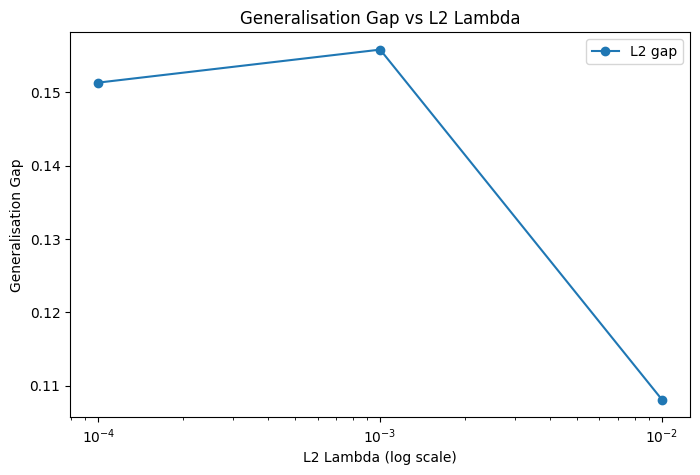

In [144]:
# GAP VS STRENGTH PLOTS 
l2_lambdas = [0.0001, 0.001, 0.01]
l2_gaps = [
    l2_train_acc_1 - l2_val_acc_1,
    l2_train_acc_2 - l2_val_acc_2,
    l2_train_acc_3 - l2_val_acc_3
]

plt.figure(figsize=(8,5))
plt.plot(l2_lambdas, l2_gaps, marker='o')
plt.xscale('log')  # lambdas span multiple orders of magnitude so log scale makes more sense here
plt.title("Generalisation Gap vs L2 Lambda")
plt.xlabel("L2 Lambda (log scale)")
plt.ylabel("Generalisation Gap")
plt.legend(["L2 gap"])
plt.show()

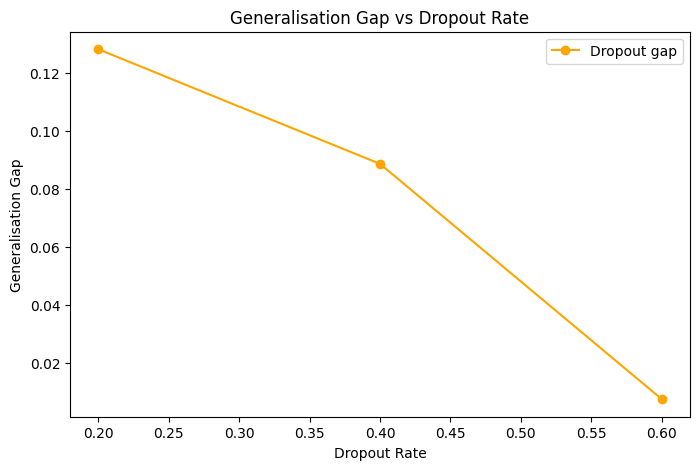

In [145]:
#GAP VS DROPOUT PLOTS 

dropout_rates = [0.2, 0.4, 0.6]
dropout_gaps = [
    dropout_train_acc_1 - dropout_val_acc_1,
    dropout_train_acc_2 - dropout_val_acc_2,
    dropout_train_acc_3 - dropout_val_acc_3
]

plt.figure(figsize=(8,5))
plt.plot(dropout_rates, dropout_gaps, marker='o', color='orange')
plt.title("Generalisation Gap vs Dropout Rate")
plt.xlabel("Dropout Rate")
plt.ylabel("Generalisation Gap")
plt.legend(["Dropout gap"])
plt.show()

Using more training data (20,000 samples) worked best overall. It brought the gap down from 0.162 to just 0.103, and training accuracy only dropped a little, from 0.9975 to 0.9735. It also gave the highest validation accuracy out of every method we tried, at 0.8705. So this method fixed the overfitting problem without losing much performance.
Dropout at rate 0.4 closed the gap even more, down to 0.081, but it came at a bigger cost — training accuracy dropped almost 9 points, from 0.9975 to 0.906. That is a much bigger trade-off for a similar improvement.
Early stopping and data augmentation were somewhere in the middle. They reduced the gap by a decent amount, but not as cheaply as adding more data.
Batch normalisation barely helped at all. Training accuracy stayed almost perfect, but validation accuracy stayed low, so the gap actually got a bit worse instead of better.
Overall, more training data was the most efficient fix, since it improved generalisation while barely hurting training accuracy. Dropout is still a strong backup option when more data simply isn't available.

# PART 7

In [146]:
# HYPERPARAMETER TUNING WITH K-FOLD CV 
import random
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

In [147]:
# search space with at least 3 hyperparameters
learning_rates = [0.01, 0.001, 0.0005, 0.0001]
hidden_units_options = [64, 128, 256]
dropout_rates = [0.0, 0.2, 0.4, 0.5]

random.seed(42)

search_space = []
count = 0
while count < 12:
    config = {
        "learning_rate": random.choice(learning_rates),
        "hidden_units": random.choice(hidden_units_options),
        "dropout_rate": random.choice(dropout_rates)
    }
    search_space.append(config)
    count += 1

i = 0
for c in search_space:
    print(i, c)
    i += 1

0 {'learning_rate': 0.01, 'hidden_units': 64, 'dropout_rate': 0.4}
1 {'learning_rate': 0.001, 'hidden_units': 64, 'dropout_rate': 0.2}
2 {'learning_rate': 0.01, 'hidden_units': 256, 'dropout_rate': 0.0}
3 {'learning_rate': 0.0001, 'hidden_units': 64, 'dropout_rate': 0.0}
4 {'learning_rate': 0.01, 'hidden_units': 64, 'dropout_rate': 0.2}
5 {'learning_rate': 0.01, 'hidden_units': 256, 'dropout_rate': 0.2}
6 {'learning_rate': 0.0001, 'hidden_units': 64, 'dropout_rate': 0.5}
7 {'learning_rate': 0.0005, 'hidden_units': 64, 'dropout_rate': 0.2}
8 {'learning_rate': 0.0001, 'hidden_units': 128, 'dropout_rate': 0.4}
9 {'learning_rate': 0.001, 'hidden_units': 64, 'dropout_rate': 0.4}
10 {'learning_rate': 0.01, 'hidden_units': 64, 'dropout_rate': 0.5}
11 {'learning_rate': 0.01, 'hidden_units': 128, 'dropout_rate': 0.4}


In [148]:
# running 5 fold cv for each of the 12 configs
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

config_id = 0
for config in search_space:
    fold_scores = []

    for train_idx, val_idx in kf.split(X_train):
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train_cat[train_idx], y_train_cat[val_idx]

        fold_model = Sequential([
            Dense(config["hidden_units"], input_dim=784, activation='relu'),
            Dropout(config["dropout_rate"]),
            Dense(config["hidden_units"], activation='relu'),
            Dropout(config["dropout_rate"]),
            Dense(10, activation='softmax')
        ])

        fold_model.compile(optimizer=Adam(learning_rate=config["learning_rate"]),
                            loss='categorical_crossentropy',
                            metrics=['accuracy'])

        # keeping epochs low here on purpose because this is just for scoring configs not final training
        fold_model.fit(X_fold_train, y_fold_train, epochs=7, batch_size=100, verbose=0)

        fold_result = fold_model.evaluate(X_fold_val, y_fold_val, verbose=0)
        fold_acc = fold_result[1]  # index 0 is loss, index 1 is accuracy
        fold_scores.append(fold_acc)

    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)

    cv_results.append({
        "config_id": config_id,
        "learning_rate": config["learning_rate"],
        "hidden_units": config["hidden_units"],
        "dropout_rate": config["dropout_rate"],
        "mean_cv_score": mean_score,
        "std_cv_score": std_score
    })

    print(f"config {config_id} done -> mean: {mean_score:.4f}, std: {std_score:.4f}")
    config_id += 1

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


config 0 done -> mean: 0.7972, std: 0.0219
config 1 done -> mean: 0.8677, std: 0.0023
config 2 done -> mean: 0.8611, std: 0.0074
config 3 done -> mean: 0.8441, std: 0.0037
config 4 done -> mean: 0.8451, std: 0.0026
config 5 done -> mean: 0.8457, std: 0.0053
config 6 done -> mean: 0.8018, std: 0.0096
config 7 done -> mean: 0.8662, std: 0.0014
config 8 done -> mean: 0.8416, std: 0.0035
config 9 done -> mean: 0.8580, std: 0.0044
config 10 done -> mean: 0.7390, std: 0.0241
config 11 done -> mean: 0.8171, std: 0.0138


In [149]:
# sorting configs by mean cv score
cv_results_df = pd.DataFrame(cv_results)
cv_results_df_sorted = cv_results_df.sort_values("mean_cv_score", ascending=False).reset_index(drop=True)

cv_results_df_sorted.head(5)

,config_id,learning_rate,hidden_units,dropout_rate,mean_cv_score,std_cv_score
0,1,0.0010,64,0.2,0.867687,0.002278
1,7,0.0005,64,0.2,0.866250,0.001377
2,2,0.0100,256,0.0,0.861104,0.007398
3,9,0.0010,64,0.4,0.858042,0.004419
4,5,0.0100,256,0.2,0.845708,0.005261


In [150]:
#picking the best config to move forward with
best_config = cv_results_df_sorted.iloc[0]
print("selected configuration:")
print(best_config)

selected configuration:
config_id         1.000000
learning_rate     0.001000
hidden_units     64.000000
dropout_rate      0.200000
mean_cv_score     0.867687
std_cv_score      0.002278
Name: 0, dtype: float64


In [151]:
#Retraining selected config on full training set
#combining with best regularisation choice from part 6 the dropout gave the best gap reduction there

final_model = Sequential([
    Dense(int(best_config["hidden_units"]), input_dim=784, activation='relu'),
    Dropout(float(best_config["dropout_rate"])),
    Dense(int(best_config["hidden_units"]), activation='relu'),
    Dropout(float(best_config["dropout_rate"])),
    Dense(10, activation='softmax')
])

final_model.compile(optimizer=Adam(learning_rate=float(best_config["learning_rate"])),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

final_history = final_model.fit(X_train, y_train_cat,
                                 validation_data=(X_val, y_val_cat),
                                 epochs=25, batch_size=100,
                                 verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7344 - loss: 0.7547 - val_accuracy: 0.8285 - val_loss: 0.4665
Epoch 2/25
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8236 - loss: 0.4955 - val_accuracy: 0.8413 - val_loss: 0.4222
Epoch 3/25
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8420 - loss: 0.4396 - val_accuracy: 0.8589 - val_loss: 0.3808
Epoch 4/25
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8516 - loss: 0.4153 - val_accuracy: 0.8630 - val_loss: 0.3693
Epoch 5/25
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8590 - loss: 0.3964 - val_accuracy: 0.8587 - val_loss: 0.3786
Epoch 6/25
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8624 - loss: 0.3823 - val_accuracy: 0.8648 - val_loss: 0.3601
Epoch 7/25
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8686 - loss: 0.3651 - val_accuracy: 0.8687 - val_loss: 0.3544
Epoch 8/25
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8707 - loss: 0.3583 - val_accuracy: 0.

In [152]:
#evaluation on test set only once
y_test_pred_probs = final_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='macro')
test_recall = recall_score(y_test, y_test_pred, average='macro')
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("test accuracy:", test_accuracy)
print("macro precision:", test_precision)
print("macro recall:", test_recall)
print("macro f1:", test_f1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
test accuracy: 0.8826
macro precision: 0.8830801968482659
macro recall: 0.8826
macro f1: 0.8820352961363959


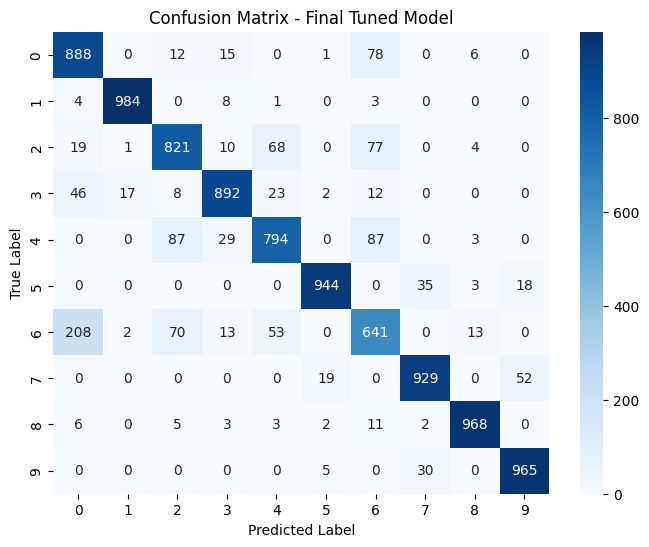

In [153]:
#confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Final Tuned Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [154]:
#Part 2 used only the validation set, so we test relu_model on the test set
part2_test_loss, part2_test_acc = relu_model.evaluate(X_test, y_test_cat, verbose=0)
print("part 2 relu baseline test accuracy:", part2_test_acc)

improvement_pp = (test_accuracy - part2_test_acc) * 100
print("improvement over part 2 baseline in percentage points:", improvement_pp)

part 2 relu baseline test accuracy: 0.8529999852180481
improvement over part 2 baseline in percentage points: 2.9600014781951955
